# Santander Customer Satisfaction: DATA 3402 Final Project 

The goal of this project is to predict customer dissatisfaction using anonymized Santander customer data. The target variable is TARGET, where 1 indicates a dissatisfied customer and 0 indicates a satisfied customer. Since the features are anonymized, the project will focus on statistical patterns, distributions, feature importance, and predictive performance rather than domain specific feature names.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [3]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (76020, 371)
Test shape: (75818, 370)


,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
0,1,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39205.170000,0
1,3,2,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.030000,0
2,4,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67333.770000,0
3,8,2,37,0.0,195.0,195.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,64007.970000,0
4,10,2,39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117310.979016,0


The training dataset contains 76020 rows and 371 columns, while the test dataset contains 75,818 rows and 370 columns. The difference of one column is expected because the training set includes the target variable (TARGET), while the test set does not. 

From the first few rows, the features appear to be numerical and anonymized. Because our variables do not have any direct meanings, the analysis will focus on statistical properties. I also noticed that many feature values are zero, which suggests that the dataset may contain scattered banking activity features.

In [4]:
print("Does train contain TARGET?", "TARGET" in train.columns)
print("Does test contain TARGET?", "TARGET" in test.columns)

train_features = set(train.columns) - {"TARGET"}
test_features = set(test.columns)

print("Number of train feature columns:", len(train_features))
print("Number of test feature columns:", len(test_features))

print("Features in train but not in test:", train_features - test_features)
print("Features in test but not in train:", test_features - train_features)

Does train contain TARGET? True
Does test contain TARGET? False
Number of train feature columns: 370
Number of test feature columns: 370
Features in train but not in test: set()
Features in test but not in train: set()


The training data contains the target variable and test data doesn't. After removing TARGET from the training columns, the training and test datasets both contain 370 matching feature columns. Now we can apply the same preprocessing steps to both.

In [5]:
dtype_counts = train.dtypes.value_counts()
print("Data type counts:")
print(dtype_counts)

non_numeric_cols = train.select_dtypes(exclude=["number"]).columns.tolist()
print("\nNon-numeric columns:")
print(non_numeric_cols)

print("\nMemory usage of train dataset:")
print(train.memory_usage(deep=True).sum() / 1024**2, "MB")

Data type counts:
int64      260
float64    111
Name: count, dtype: int64

Non-numeric columns:
[]

Memory usage of train dataset:
215.17514419555664 MB


The dataset contains only numerical variables (260 integer columns and 111 floating-point columns). Categorical encoding not required.

In [6]:
train_missing_total = train.isnull().sum().sum()
test_missing_total = test.isnull().sum().sum()

print("Total missing values in train:", train_missing_total)
print("Total missing values in test:", test_missing_total)

train_missing_cols = train.isnull().sum()
train_missing_cols = train_missing_cols[train_missing_cols > 0].sort_values(ascending=False)

test_missing_cols = test.isnull().sum()
test_missing_cols = test_missing_cols[test_missing_cols > 0].sort_values(ascending=False)

print("\nColumns with missing values in train:")
print(train_missing_cols)

print("\nColumns with missing values in test:")
print(test_missing_cols)

Total missing values in train: 0
Total missing values in test: 0

Columns with missing values in train:
Series([], dtype: int64)

Columns with missing values in test:
Series([], dtype: int64)


No missing values!! This simplifies the preprocessing because I dont need to fill missing values or remove any rows. But, no null values doesn't mean that there are no abnormal values, so I'll inspect feature distributions and outliers later.

Target counts:
TARGET
0    73012
1     3008
Name: count, dtype: int64

Target percentages:
TARGET
0    96.043147
1     3.956853
Name: proportion, dtype: float64


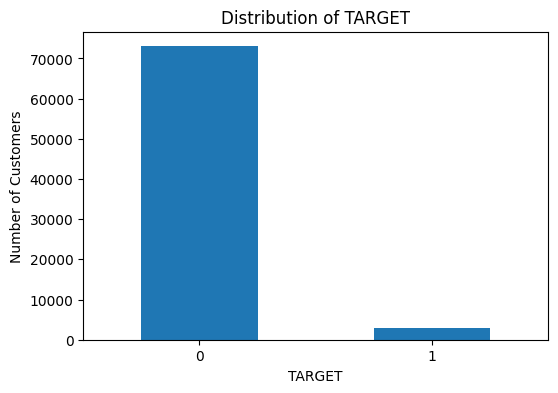

In [7]:
target_counts = train["TARGET"].value_counts().sort_index()
target_percentages = train["TARGET"].value_counts(normalize=True).sort_index() * 100

print("Target counts:")
print(target_counts)

print("\nTarget percentages:")
print(target_percentages)

plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")
plt.title("Distribution of TARGET")
plt.xlabel("TARGET")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

The target variable is highly imbalanced. About 96% of customers belong to class 0, while only 3.96% belong to class 1. This means that dissatisfied customers are rare here.

In [8]:
majority_class_accuracy = target_counts[0] / target_counts.sum()

print("Majority class baseline accuracy:", majority_class_accuracy)
print("Majority class baseline accuracy (%):", majority_class_accuracy * 100)

Majority class baseline accuracy: 0.9604314654038411
Majority class baseline accuracy (%): 96.0431465403841


The majority class baseline accuracy is 96.04%. This means that a model could predict every customer as class 0 and still achieve high accuracy because the dataset is so heavily imbalanced. But, this model would not be able to detect dissatisfied customers (1).

So, instead of just accuracy, I will use this baseline as a reference point and evaluate future models using recall, precision, F1-score, ROC-AUC, and confusion matrix.

In [9]:
duplicate_rows = train.duplicated().sum()

print("Number of duplicate rows in train:", duplicate_rows)
print("Percentage of duplicate rows:", duplicate_rows / len(train) * 100)

Number of duplicate rows in train: 0
Percentage of duplicate rows: 0.0


Each observation is unique, so no rows need to be removed for duplication.

In [10]:
print("Number of rows in train:", len(train))
print("Number of unique train IDs:", train["ID"].nunique())
print("Number of rows in test:", len(test))
print("Number of unique test IDs:", test["ID"].nunique())

print("\nFirst 10 train IDs:")
print(train["ID"].head(10).tolist())

print("\nFirst 10 test IDs:")
print(test["ID"].head(10).tolist())

Number of rows in train: 76020
Number of unique train IDs: 76020
Number of rows in test: 75818
Number of unique test IDs: 75818

First 10 train IDs:
[1, 3, 4, 8, 10, 13, 14, 18, 20, 23]

First 10 test IDs:
[2, 5, 6, 7, 9, 11, 12, 15, 16, 17]


The ID column is unique for every row in both the training and test datasets, which means it is an identifier rather than a predictive feature. Since it does not represent customer behavior or account information, I wont use it as an input feature for model training.

In [11]:
feature_cols = [col for col in train.columns if col != "TARGET"]

nunique_values = train[feature_cols].nunique().sort_values()

constant_features = nunique_values[nunique_values == 1].index.tolist()

print("Number of constant features:", len(constant_features))
print("Constant features:")
print(constant_features)

print("\nFirst 20 features with lowest number of unique values:")
print(nunique_values.head(20))

Number of constant features: 34
Constant features:
['saldo_var2_ult1', 'saldo_var28', 'imp_reemb_var13_hace3', 'ind_var28_0', 'ind_var2_0', 'ind_var2', 'imp_reemb_var33_hace3', 'saldo_var27', 'ind_var28', 'num_trasp_var33_out_hace3', 'saldo_medio_var13_medio_hace3', 'num_var46', 'num_var46_0', 'ind_var27', 'imp_trasp_var33_out_hace3', 'ind_var41', 'imp_trasp_var17_out_hace3', 'ind_var27_0', 'imp_amort_var18_hace3', 'num_trasp_var17_out_hace3', 'num_var27_0', 'num_var28_0', 'ind_var46_0', 'num_reemb_var33_hace3', 'imp_amort_var34_hace3', 'ind_var46', 'num_var27', 'num_reemb_var13_hace3', 'num_var2_0_ult1', 'saldo_var46', 'num_var2_ult1', 'saldo_var41', 'num_var28', 'num_var41']

First 20 features with lowest number of unique values:
saldo_var2_ult1                  1
saldo_var28                      1
imp_reemb_var13_hace3            1
ind_var28_0                      1
ind_var2_0                       1
ind_var2                         1
imp_reemb_var33_hace3            1
saldo_var27  

I found 34 constant features in the training dataset. A constant feature has only one unique value across all training observations. Since these columns contain no information that can help distinguish satisfied from dissatisfied customers, they are gonna be removed from the feature set.

In [12]:
train_clean = train.copy()
test_clean = test.copy()

train_clean = train_clean.drop(columns=constant_features)

constant_features_in_test = [col for col in constant_features if col in test_clean.columns]
test_clean = test_clean.drop(columns=constant_features_in_test)

print("Original train shape:", train.shape)
print("Cleaned train shape:", train_clean.shape)

print("Original test shape:", test.shape)
print("Cleaned test shape:", test_clean.shape)

print("Number of removed constant features:", len(constant_features))

Original train shape: (76020, 371)
Cleaned train shape: (76020, 337)
Original test shape: (75818, 370)
Cleaned test shape: (75818, 336)
Number of removed constant features: 34


In [13]:
feature_cols_clean = [col for col in train_clean.columns if col != "TARGET"]

top_value_ratios = train_clean[feature_cols_clean].apply(
    lambda col: col.value_counts(normalize=True, dropna=False).iloc[0]
).sort_values(ascending=False)

print("Top 20 near-constant features by most frequent value ratio:")
print(top_value_ratios.head(20))

near_constant_features_99 = top_value_ratios[top_value_ratios > 0.99].index.tolist()

print("\nNumber of features where one value appears in more than 99% of rows:")
print(len(near_constant_features_99))

print("\nNear-constant features > 99%:")
print(near_constant_features_99[:30])

Top 20 near-constant features by most frequent value ratio:
imp_reemb_var33_ult1             0.999987
saldo_medio_var29_hace3          0.999987
imp_trasp_var33_out_ult1         0.999987
num_reemb_var17_hace3            0.999987
num_reemb_var33_ult1             0.999987
imp_reemb_var17_hace3            0.999987
delta_num_trasp_var33_out_1y3    0.999987
delta_num_reemb_var33_1y3        0.999987
num_trasp_var33_out_ult1         0.999987
delta_imp_reemb_var33_1y3        0.999987
delta_imp_trasp_var33_out_1y3    0.999987
saldo_var34                      0.999974
delta_imp_amort_var18_1y3        0.999974
ind_var18_0                      0.999974
ind_var18                        0.999974
num_var34_0                      0.999974
imp_trasp_var17_in_hace3         0.999974
num_var34                        0.999974
ind_var29                        0.999974
saldo_var6                       0.999974
dtype: float64

Number of features where one value appears in more than 99% of rows:
187

Near-const

--------
I checked for near-constant features by calculating the proportion of the most frequent value in each column. A near-constant feature is not completely constant, but one value appears in almost all rows.

The output shows that 187 features have one value appearing in more than 99% of the training observations. This suggests that many variables are sparse, meaning most customers have the same value, often likely zero, while only a small number of customers have different values.

-- I used AI (ChatGPT) here to better understand the concept of near-constant features and how to write the code for identifying them as I didn't know before. I was confused about the difference between constant and near-constant variables, so I used AI to help explain why these features matter and how to interpret them. Based on the output, I understand that constant features provide no information, while near-constant features may still contain useful signal because rare values could be related to the rare target class.

Since the target class is also rare, I will not automatically remove all near-constant features at this point. Instead, I will inspect whether the rare values in some of these columns are associated with customer dissatisfaction. 

----

In [14]:
near_constant_summary = []

for col in top_value_ratios.head(20).index:
    dominant_value = train_clean[col].value_counts(dropna=False).index[0]
    dominant_mask = train_clean[col] == dominant_value
    rare_mask = ~dominant_mask
    
    dominant_count = dominant_mask.sum()
    rare_count = rare_mask.sum()
    
    dominant_target_rate = train_clean.loc[dominant_mask, "TARGET"].mean()
    rare_target_rate = train_clean.loc[rare_mask, "TARGET"].mean() if rare_count > 0 else np.nan
    
    near_constant_summary.append({
        "Feature": col,
        "Dominant Value": dominant_value,
        "Dominant Count": dominant_count,
        "Rare Count": rare_count,
        "Dominant Target Rate": dominant_target_rate,
        "Rare Target Rate": rare_target_rate
    })

near_constant_summary = pd.DataFrame(near_constant_summary)

near_constant_summary

,Feature,Dominant Value,Dominant Count,Rare Count,Dominant Target Rate,Rare Target Rate
0,imp_reemb_var33_ult1,0.0,76019,1,0.039569,0.0
1,saldo_medio_var29_hace3,0.0,76019,1,0.039569,0.0
2,imp_trasp_var33_out_ult1,0.0,76019,1,0.039569,0.0
3,num_reemb_var17_hace3,0.0,76019,1,0.039569,0.0
4,num_reemb_var33_ult1,0.0,76019,1,0.039569,0.0
5,imp_reemb_var17_hace3,0.0,76019,1,0.039569,0.0
6,delta_num_trasp_var33_out_1y3,0.0,76019,1,0.039569,0.0
7,delta_num_reemb_var33_1y3,0.0,76019,1,0.039569,0.0
8,num_trasp_var33_out_ult1,0.0,76019,1,0.039569,0.0
9,delta_imp_reemb_var33_1y3,0.0,76019,1,0.039569,0.0


Earlier, I identified features where more than 99% of the rows contain the same value. These features may provide limited predictive signal because they vary for only a very small number of customers. However, since rare events may still be informative in an imbalanced classification problem, I did not remove them immediately.

To make a more principled decision, I compared model performance with and without near-constant features.

In [15]:
feature_cols_clean = [col for col in train_clean.columns if col != "TARGET"]

top_value_ratios = train_clean[feature_cols_clean].apply(
    lambda col: col.value_counts(normalize=True, dropna=False).iloc[0]
)

near_constant_features = top_value_ratios[top_value_ratios > 0.99].index.tolist()

if "ID" in near_constant_features:
    near_constant_features.remove("ID")

print("Number of near-constant features:", len(near_constant_features))
print("First 10 near-constant features:", near_constant_features[:10])

Number of near-constant features: 187
First 10 near-constant features: ['imp_op_var40_comer_ult1', 'imp_op_var40_comer_ult3', 'imp_op_var40_efect_ult1', 'imp_op_var40_efect_ult3', 'imp_op_var40_ult1', 'imp_sal_var16_ult1', 'ind_var1', 'ind_var6_0', 'ind_var6', 'ind_var13_largo']


For the top 20 near-constant features, the dominant value is 0. In many of these columns, the dominant value appears in 76,018 or 76,019 rows, meaning only 1 or 2 observations contain a rare value.

The dominant target rate is approximately 0.0396, which matches the overall minority-class rate. The rare target rate for these top near-constant features is 0.0, meaning the few rare observations in these columns do not correspond to dissatisfied customers. However, because the rare counts are extremely small, I think that I should be cautious about making strong conclusions from these features alone, as I don't want to go off the track.

I wont remove all near-constant features automatically yet because some sparse features with larger rare counts may still contain useful signal for identifying the rare target class.

Top 20 features with highest zero ratio:
num_reemb_var33_ult1             0.999987
num_trasp_var33_out_ult1         0.999987
delta_imp_reemb_var33_1y3        0.999987
imp_trasp_var33_out_ult1         0.999987
saldo_medio_var29_hace3          0.999987
imp_reemb_var33_ult1             0.999987
delta_imp_trasp_var33_out_1y3    0.999987
delta_num_reemb_var33_1y3        0.999987
imp_reemb_var17_hace3            0.999987
delta_num_trasp_var33_out_1y3    0.999987
num_reemb_var17_hace3            0.999987
saldo_var34                      0.999974
saldo_var29                      0.999974
delta_imp_amort_var18_1y3        0.999974
delta_imp_amort_var34_1y3        0.999974
ind_var34                        0.999974
num_meses_var13_medio_ult3       0.999974
imp_trasp_var17_in_hace3         0.999974
ind_var13_medio_0                0.999974
ind_var13_medio                  0.999974
dtype: float64

Summary of zero ratios across all features:
count    336.000000
mean       0.897104
std        0.237974

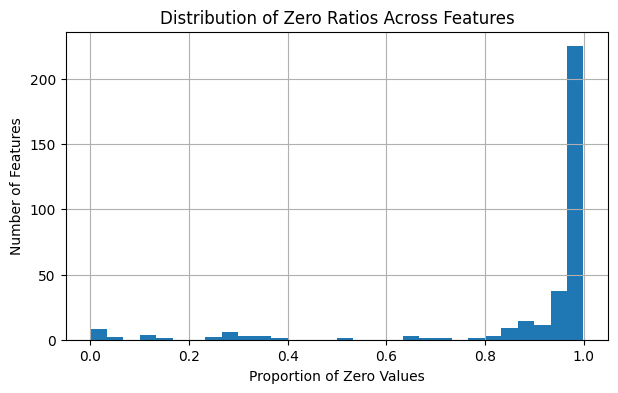

In [16]:
feature_cols_clean = [col for col in train_clean.columns if col != "TARGET"]

zero_ratios = (train_clean[feature_cols_clean] == 0).mean().sort_values(ascending=False)

print("Top 20 features with highest zero ratio:")
print(zero_ratios.head(20))

print("\nSummary of zero ratios across all features:")
print(zero_ratios.describe())

plt.figure(figsize=(7, 4))
zero_ratios.hist(bins=30)
plt.title("Distribution of Zero Ratios Across Features")
plt.xlabel("Proportion of Zero Values")
plt.ylabel("Number of Features")
plt.show()

I analyzed the proportion of zero values in each feature to understand sparsity in the dataset. The dataset is highly sparse as it seems. The average feature has about 89.7% zero values, and the median feature has about 99.6% zero values. This means that more than half of the features are zero for almost all customers.

This supports the earlier observation from "train.head()" that many feature values are 0.0. Since the variables are anonymized, I cannot directly explain what each zero means unfortunately, but the pattern suggests that many features may represent rare banking activities or indicators that apply only to a small number of customers.

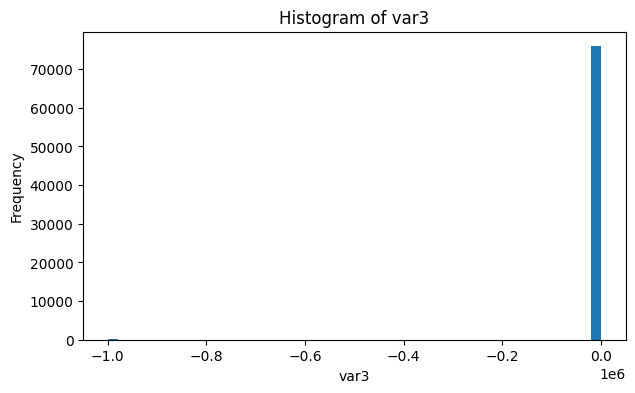


Summary statistics for var3:
count     76020.000000
mean      -1523.199277
std       39033.462364
min     -999999.000000
25%           2.000000
50%           2.000000
75%           2.000000
max         238.000000
Name: var3, dtype: float64
Top 10 most frequent values:
var3
 2         74165
 8           138
-999999      116
 9           110
 3           108
 1           105
 13           98
 7            97
 4            86
 12           85
Name: count, dtype: int64


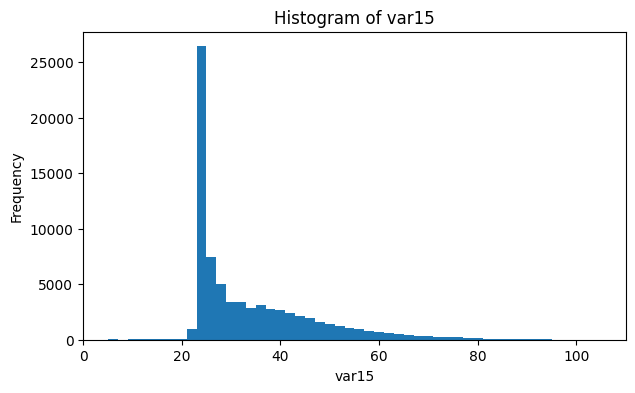


Summary statistics for var15:
count    76020.000000
mean        33.212865
std         12.956486
min          5.000000
25%         23.000000
50%         28.000000
75%         40.000000
max        105.000000
Name: var15, dtype: float64
Top 10 most frequent values:
var15
23    20170
24     6232
25     4217
26     3270
27     2861
28     2173
31     1798
29     1727
30     1640
32     1592
Name: count, dtype: int64


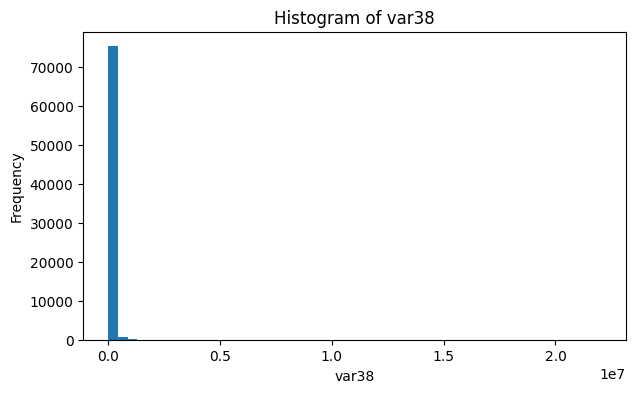


Summary statistics for var38:
count    7.602000e+04
mean     1.172358e+05
std      1.826646e+05
min      5.163750e+03
25%      6.787061e+04
50%      1.064092e+05
75%      1.187563e+05
max      2.203474e+07
Name: var38, dtype: float64
Top 10 most frequent values:
var38
117310.979016    14868
451931.220000       16
463625.160000       12
288997.440000       11
104563.800000       11
236690.340000        8
104644.410000        7
125722.440000        7
67088.310000         7
329603.970000        7
Name: count, dtype: int64


In [17]:
selected_features = ["var3", "var15", "var38"]

for col in selected_features:
    plt.figure(figsize=(7, 4))
    plt.hist(train_clean[col], bins=50)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

    print(f"\nSummary statistics for {col}:")
    print(train_clean[col].describe())
    print("Top 10 most frequent values:")
    print(train_clean[col].value_counts().head(10))

I plotted histograms for var3, var15, and var38 to understand different types of feature distributions in the dataset.

1. The histogram for var3 shows that most observations have the value 2, but there is also an extreme value of -999999 that appears 116 times. This value is far outside the normal range of the feature and may represent an encoded missing value, special category, or something. Because it strongly affects the scale of the histogram and summary statistics, it needs to be handled carefully before modeling.

2. The histogram for var15 shows a right skewed distribution. Most values are concentrated between the 20s and 40s, with fewer observations at higher values. This feature has meaningful variation across customers and may contain useful predictive information!

3. The histogram for var38 is also highly right skewed. Most values are concentrated near the lower range, but a few very large values stretch the distribution. The feature also has one repeated value, 117310.979016, that appears many times. This could mean that var38 may contain a common default-like value along with a long-tailed numerical distribution.

In [18]:
var3_extreme_mask = train_clean["var3"] == -999999

print("Number of rows where var3 = -999999:", var3_extreme_mask.sum())
print("Percentage of rows where var3 = -999999:", var3_extreme_mask.mean() * 100)

print("\nTARGET distribution when var3 = -999999:")
print(train_clean.loc[var3_extreme_mask, "TARGET"].value_counts())
print(train_clean.loc[var3_extreme_mask, "TARGET"].value_counts(normalize=True) * 100)

print("\nTARGET distribution when var3 != -999999:")
print(train_clean.loc[~var3_extreme_mask, "TARGET"].value_counts())
print(train_clean.loc[~var3_extreme_mask, "TARGET"].value_counts(normalize=True) * 100)

Number of rows where var3 = -999999: 116
Percentage of rows where var3 = -999999: 0.15259142330965536

TARGET distribution when var3 = -999999:
TARGET
0    114
1      2
Name: count, dtype: int64
TARGET
0    98.275862
1     1.724138
Name: proportion, dtype: float64

TARGET distribution when var3 != -999999:
TARGET
0    72898
1     3006
Name: count, dtype: int64
TARGET
0    96.039734
1     3.960266
Name: proportion, dtype: float64


In [19]:
valid_var3_median = train_clean.loc[train_clean["var3"] != -999999, "var3"].median()

print("Median var3 excluding -999999:", valid_var3_median)

train_clean["var3"] = train_clean["var3"].replace(-999999, valid_var3_median)

if "var3" in test_clean.columns:
    test_clean["var3"] = test_clean["var3"].replace(-999999, valid_var3_median)

print("Number of -999999 values in train_clean var3 after replacement:", (train_clean["var3"] == -999999).sum())
print("Number of -999999 values in test_clean var3 after replacement:", (test_clean["var3"] == -999999).sum())

print("\nUpdated var3 summary:")
print(train_clean["var3"].describe())

Median var3 excluding -999999: 2.0
Number of -999999 values in train_clean var3 after replacement: 0
Number of -999999 values in test_clean var3 after replacement: 0

Updated var3 summary:
count    76020.000000
mean         2.716483
std          9.447971
min          0.000000
25%          2.000000
50%          2.000000
75%          2.000000
max        238.000000
Name: var3, dtype: float64


I replaced the extreme encoded value -999999 in var3 with the median of valid training values. The median excluding -999999 was 2.0. After replacement, there are no remaining -999999 values in either dataset. The updated summary statistics for var3 are more reasonable: the mean is 2.72, the standard deviation is 9.45, and the range is now 0 to 238.

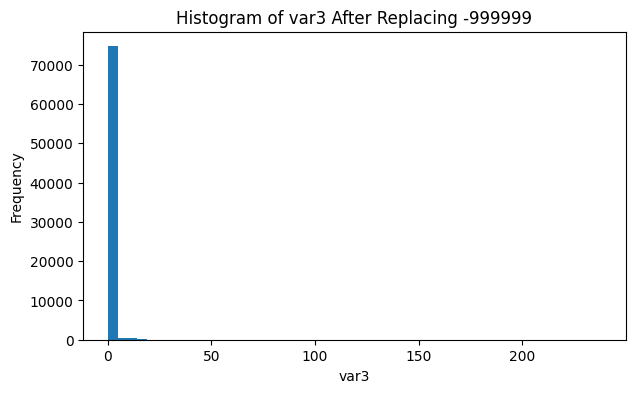

Top 10 most frequent values in cleaned var3:
var3
2     74281
8       138
9       110
3       108
1       105
13       98
7        97
4        86
12       85
6        82
Name: count, dtype: int64


In [20]:
plt.figure(figsize=(7, 4))
plt.hist(train_clean["var3"], bins=50)
plt.title("Histogram of var3 After Replacing -999999")
plt.xlabel("var3")
plt.ylabel("Frequency")
plt.show()

print("Top 10 most frequent values in cleaned var3:")
print(train_clean["var3"].value_counts().head(10))

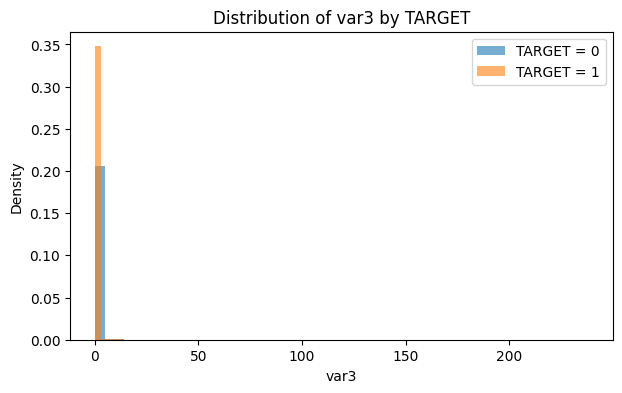

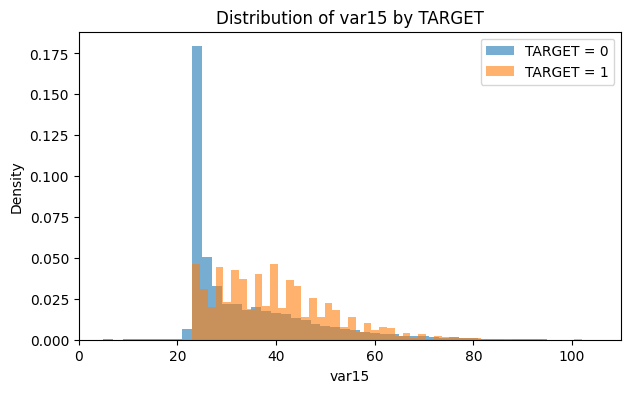

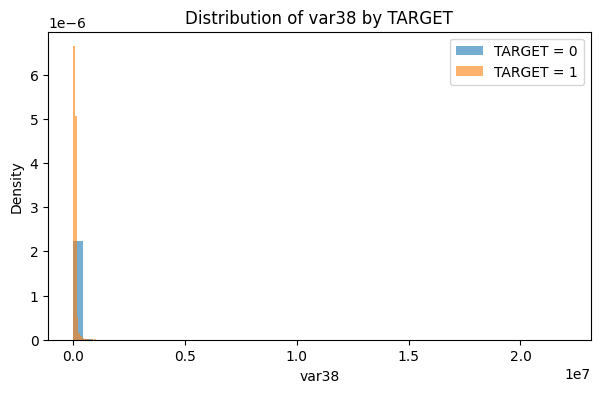

In [21]:
selected_features = ["var3", "var15", "var38"]

for col in selected_features:
    plt.figure(figsize=(7, 4))
    
    plt.hist(
        train_clean.loc[train_clean["TARGET"] == 0, col],
        bins=50,
        alpha=0.6,
        density=True,
        label="TARGET = 0"
    )
    
    plt.hist(
        train_clean.loc[train_clean["TARGET"] == 1, col],
        bins=50,
        alpha=0.6,
        density=True,
        label="TARGET = 1"
    )
    
    plt.title(f"Distribution of {col} by TARGET")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
    plt.show()

I compared the distributions of selected features by `TARGET` to see if the variables show different patterns for satisfied and dissatisfied customers.

For `var3`, both target classes are concentrated around similar low values, so there is no strong visual separation between `TARGET = 0` and `TARGET = 1`. This means that `var3` may not be a strong standalone predictor.

For `var15`, the distributions are more distinct. The dissatisfied customers (`TARGET = 1`) appear to have a distribution shifted toward higher values compared with satisfied customers (`TARGET = 0`). This means that `var15` may contain useful predictive signal.

For `var38`, both classes are concentrated near the lower range, but the feature is highly right-skewed with very large values. Because the long tail compresses the histogram, the raw-scale plot is difficult to interpret.

In [22]:
selected_features = ["var3", "var15", "var38"]

for col in selected_features:
    print(f"\nSummary statistics for {col} by TARGET:")
    display(
        train_clean.groupby("TARGET")[col].agg(
            ["count", "mean", "median", "std", "min", "max"]
        )
    )


Summary statistics for var3 by TARGET:


,count,mean,median,std,min,max
TARGET,,,,,,
0,73012,2.736742,2.0,9.598223,0,238
1,3008,2.224734,2.0,4.422487,0,142



Summary statistics for var15 by TARGET:


,count,mean,median,std,min,max
TARGET,,,,,,
0,73012,32.946406,27.0,12.924444,5,105
1,3008,39.680519,38.0,12.020518,23,102



Summary statistics for var38 by TARGET:


,count,mean,median,std,min,max
TARGET,,,,,,
0,73012,117959.156918,107207.82,185100.867998,5163.75,22034738.76
1,3008,99678.280590,86219.97,106309.811490,11136.63,3988595.10


For `var3`, both target classes have the same median value of 2.0, and the means are relatively close. `var3` does not strongly separate satisfied and dissatisfied customers on its own.

For `var15`, the difference between target classes is much clearer. Customers with `TARGET = 1` have a higher mean and median value than customers with `TARGET = 0`. The median for dissatisfied customers is 38.0 compared with 27.0 for satisfied customers. 

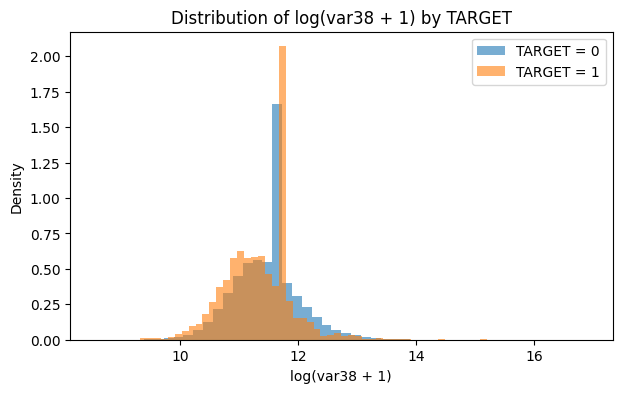

Summary statistics for log_var38 by TARGET:


,count,mean,median,std,min,max
TARGET,,,,,,
0,73012,11.488613,11.582534,0.559484,8.549612,16.908131
1,3008,11.328052,11.364669,0.565219,9.318085,15.198950


In [23]:
train_clean["log_var38"] = np.log1p(train_clean["var38"])

plt.figure(figsize=(7, 4))
plt.hist(
    train_clean.loc[train_clean["TARGET"] == 0, "log_var38"],
    bins=50,
    alpha=0.6,
    density=True,
    label="TARGET = 0"
)

plt.hist(
    train_clean.loc[train_clean["TARGET"] == 1, "log_var38"],
    bins=50,
    alpha=0.6,
    density=True,
    label="TARGET = 1"
)

plt.title("Distribution of log(var38 + 1) by TARGET")
plt.xlabel("log(var38 + 1)")
plt.ylabel("Density")
plt.legend()
plt.show()

print("Summary statistics for log_var38 by TARGET:")
display(
    train_clean.groupby("TARGET")["log_var38"].agg(
        ["count", "mean", "median", "std", "min", "max"]
    )
)

I applied a log transformation to var38 (with help of AI explaining the concepts behind this and how to write the code for it) for visualization because the original feature was highly right-skewed and contained very large values. The log transformation compresses extreme values and makes the distribution easier to compare across target classes.

Customers with TARGET = 1 have a slightly lower mean and median log-transformed var38 value than customers with TARGET = 0. However, the two distributions still overlap substantially, so var38 is stilll not a strong standalone separator.

In [24]:
if "log_var38" in train_clean.columns:
    train_clean = train_clean.drop(columns=["log_var38"])

print("train_clean shape after removing temporary log_var38:", train_clean.shape)

train_clean shape after removing temporary log_var38: (76020, 337)


Top 20 features by absolute correlation with TARGET:
ind_var30             -0.149811
num_meses_var5_ult3   -0.148253
num_var30             -0.138289
num_var42             -0.135693
ind_var5              -0.135349
num_var5              -0.134095
var36                  0.102919
var15                  0.101322
num_var4              -0.080194
num_var35             -0.076872
ind_var8_0             0.046665
num_var8_0             0.046622
ind_var13             -0.039612
ind_var13_0           -0.039471
num_var13             -0.038400
ind_var12_0           -0.038215
num_var13_0           -0.038045
saldo_var30           -0.037092
ind_var39_0           -0.035045
ind_var13_corto       -0.034438
Name: TARGET, dtype: float64


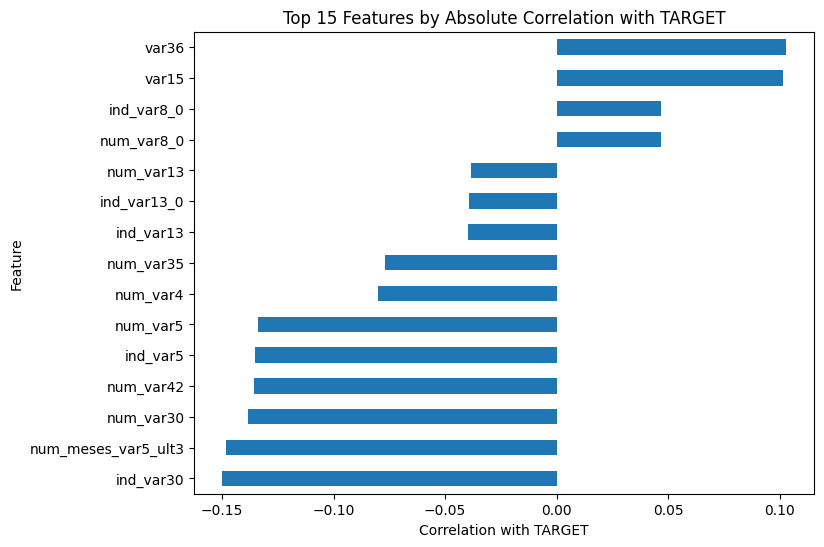

In [25]:
feature_cols_clean = [col for col in train_clean.columns if col != "TARGET"]

target_correlations = train_clean[feature_cols_clean + ["TARGET"]].corr()["TARGET"].drop("TARGET")

target_correlations_sorted = target_correlations.reindex(
    target_correlations.abs().sort_values(ascending=False).index
)

print("Top 20 features by absolute correlation with TARGET:")
print(target_correlations_sorted.head(20))

plt.figure(figsize=(8, 6))
target_correlations_sorted.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Features by Absolute Correlation with TARGET")
plt.xlabel("Correlation with TARGET")
plt.ylabel("Feature")
plt.show()

The strongest correlations are relatively small, with the largest absolute correlation around 0.15. This suggests that no single feature strongly separates satisfied and dissatisfied customers by itself. The prediction task then likely requires combining many weak signals across multiple variables.

Lots of features like `ind_var30`, `num_meses_var5_ult3`, `num_var30`, `num_var42`, and `ind_var5`, have negative correlations with TARGET. This means higher values of these features are associated with a lower likelihood of dissatisfaction. In contrast, `var36` and `var15` have positive correlations, meaning higher values are associated with a higher likelihood of dissatisfaction.

Top correlated features selected for visualization:
['ind_var30', 'num_meses_var5_ult3', 'num_var30', 'num_var42', 'ind_var5', 'num_var5']


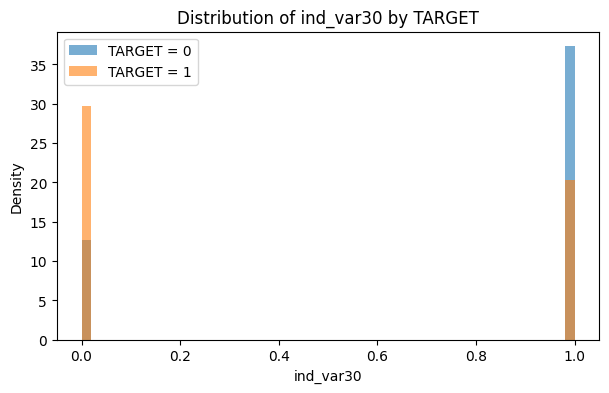

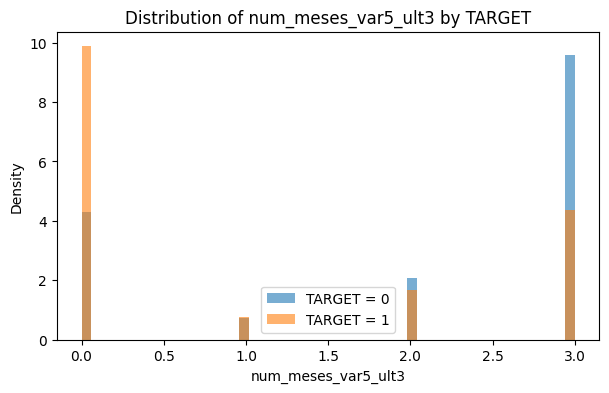

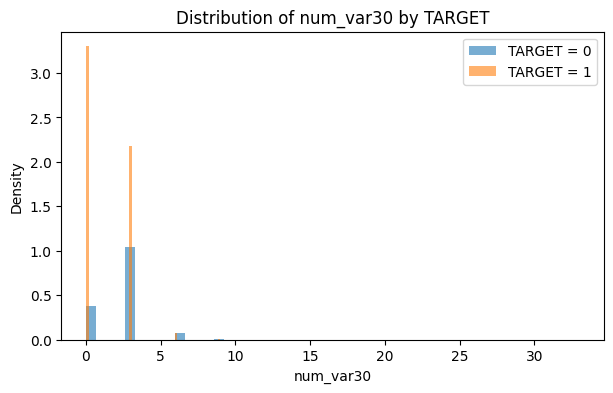

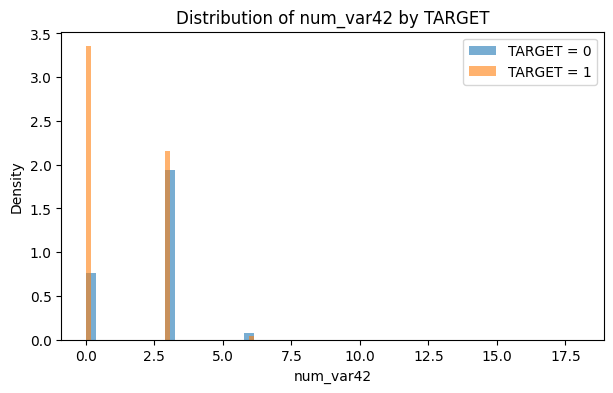

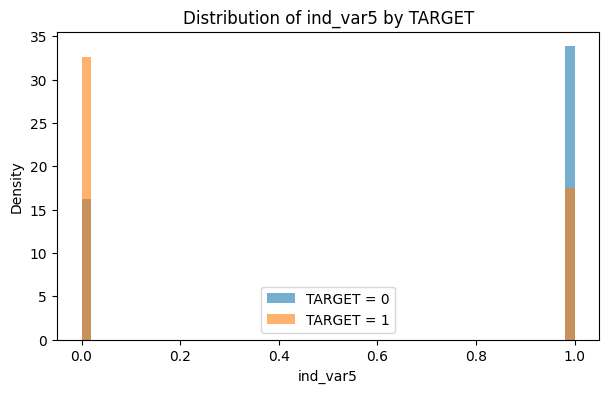

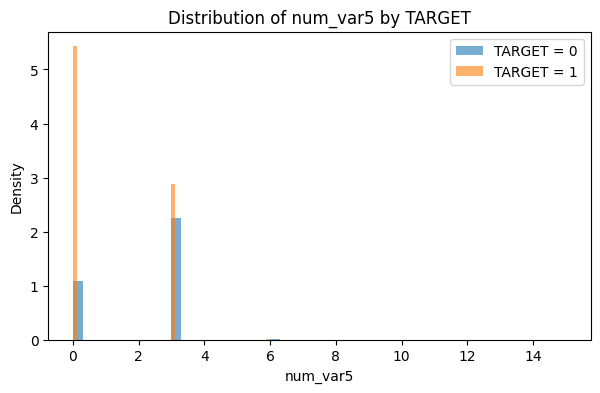

In [26]:
top_corr_features = target_correlations_sorted.head(6).index.tolist()

print("Top correlated features selected for visualization:")
print(top_corr_features)

for col in top_corr_features:
    plt.figure(figsize=(7, 4))
    
    plt.hist(
        train_clean.loc[train_clean["TARGET"] == 0, col],
        bins=50,
        alpha=0.6,
        density=True,
        label="TARGET = 0"
    )
    
    plt.hist(
        train_clean.loc[train_clean["TARGET"] == 1, col],
        bins=50,
        alpha=0.6,
        density=True,
        label="TARGET = 1"
    )
    
    plt.title(f"Distribution of {col} by TARGET")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
    plt.show()

The plots show that several of the negatively correlated features, such as `ind_var30`, `num_meses_var5_ult3`, `num_var30`, `num_var42`, `ind_var5`, and `num_var5`, have more `TARGET = 1` density at lower values, especially 0. In contrast, `TARGET = 0` has relatively more density at higher or positive values.

In [27]:
feature_cols_clean = [col for col in train_clean.columns if col != "TARGET"]

duplicate_columns = []
seen_columns = {}

for col in feature_cols_clean:
    col_values = tuple(train_clean[col].values)
    
    if col_values in seen_columns:
        duplicate_columns.append((col, seen_columns[col_values]))
    else:
        seen_columns[col_values] = col

print("Number of duplicate feature columns:", len(duplicate_columns))

print("\nFirst 20 duplicate column pairs:")
for duplicate_col, original_col in duplicate_columns[:20]:
    print(f"{duplicate_col} is duplicate of {original_col}")

Number of duplicate feature columns: 29

First 20 duplicate column pairs:
ind_var13_medio is duplicate of ind_var13_medio_0
ind_var18 is duplicate of ind_var18_0
ind_var26 is duplicate of ind_var26_0
ind_var25 is duplicate of ind_var25_0
ind_var29_0 is duplicate of ind_var6_0
ind_var29 is duplicate of ind_var6
ind_var32 is duplicate of ind_var32_0
ind_var34 is duplicate of ind_var34_0
ind_var37 is duplicate of ind_var37_0
ind_var39 is duplicate of ind_var40
num_var13_medio is duplicate of num_var13_medio_0
num_var18 is duplicate of num_var18_0
num_var26 is duplicate of num_var26_0
num_var25 is duplicate of num_var25_0
num_var29_0 is duplicate of num_var6_0
num_var29 is duplicate of num_var6
num_var32 is duplicate of num_var32_0
num_var34 is duplicate of num_var34_0
num_var37 is duplicate of num_var37_0
num_var39 is duplicate of num_var40


In [28]:
duplicate_cols_to_remove = [duplicate_col for duplicate_col, original_col in duplicate_columns]

train_clean = train_clean.drop(columns=duplicate_cols_to_remove)

duplicate_cols_in_test = [col for col in duplicate_cols_to_remove if col in test_clean.columns]
test_clean = test_clean.drop(columns=duplicate_cols_in_test)

print("Number of duplicate columns removed:", len(duplicate_cols_to_remove))
print("train_clean shape after removing duplicate columns:", train_clean.shape)
print("test_clean shape after removing duplicate columns:", test_clean.shape)

Number of duplicate columns removed: 29
train_clean shape after removing duplicate columns: (76020, 308)
test_clean shape after removing duplicate columns: (75818, 307)


In [29]:
train_features_clean = set(train_clean.columns) - {"TARGET"}
test_features_clean = set(test_clean.columns)

print("Cleaned train shape:", train_clean.shape)
print("Cleaned test shape:", test_clean.shape)

print("Number of cleaned train features:", len(train_features_clean))
print("Number of cleaned test features:", len(test_features_clean))

print("Features in train_clean but not in test_clean:", train_features_clean - test_features_clean)
print("Features in test_clean but not in train_clean:", test_features_clean - train_features_clean)

print("\nDoes train_clean contain TARGET?", "TARGET" in train_clean.columns)
print("Does test_clean contain TARGET?", "TARGET" in test_clean.columns)

Cleaned train shape: (76020, 308)
Cleaned test shape: (75818, 307)
Number of cleaned train features: 307
Number of cleaned test features: 307
Features in train_clean but not in test_clean: set()
Features in test_clean but not in train_clean: set()

Does train_clean contain TARGET? True
Does test_clean contain TARGET? False


In [30]:
from sklearn.model_selection import train_test_split

X = train_clean.drop(columns=["TARGET", "ID"])
y = train_clean["TARGET"]

X_test_final = test_clean.drop(columns=["ID"])

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True) * 100)

X_train shape: (60816, 306)
X_val shape: (15204, 306)
y_train shape: (60816,)
y_val shape: (15204,)

Training target distribution:
TARGET
0    96.043804
1     3.956196
Name: proportion, dtype: float64

Validation target distribution:
TARGET
0    96.040516
1     3.959484
Name: proportion, dtype: float64


I separated the cleaned dataset into features X and target variable y, then created an 80/20 train-validation split. Because the target variable is highly imbalanced, I used stratification to preserve the same class distribution in both the training and validation sets.

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

baseline_preds = np.zeros_like(y_val)

baseline_accuracy = accuracy_score(y_val, baseline_preds)
baseline_precision = precision_score(y_val, baseline_preds, zero_division=0)
baseline_recall = recall_score(y_val, baseline_preds, zero_division=0)
baseline_f1 = f1_score(y_val, baseline_preds, zero_division=0)
baseline_cm = confusion_matrix(y_val, baseline_preds)

print("Baseline Model Performance")
print("Accuracy:", baseline_accuracy)
print("Precision:", baseline_precision)
print("Recall:", baseline_recall)
print("F1-score:", baseline_f1)

print("\nConfusion Matrix:")
print(baseline_cm)

print("\nClassification Report:")
print(classification_report(y_val, baseline_preds, zero_division=0))

Baseline Model Performance
Accuracy: 0.9604051565377533
Precision: 0.0
Recall: 0.0
F1-score: 0.0

Confusion Matrix:
[[14602     0]
 [  602     0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     14602
           1       0.00      0.00      0.00       602

    accuracy                           0.96     15204
   macro avg       0.48      0.50      0.49     15204
weighted avg       0.92      0.96      0.94     15204



The confusion matrix shows that it correctly classifies all 14,602 satisfied customers but misses all 602 dissatisfied customers.

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

log_reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

log_reg_pipeline.fit(X_train, y_train)

log_reg_preds = log_reg_pipeline.predict(X_val)
log_reg_probs = log_reg_pipeline.predict_proba(X_val)[:, 1]

print("Logistic Regression Performance")
print("Accuracy:", accuracy_score(y_val, log_reg_preds))
print("Precision:", precision_score(y_val, log_reg_preds, zero_division=0))
print("Recall:", recall_score(y_val, log_reg_preds, zero_division=0))
print("F1-score:", f1_score(y_val, log_reg_preds, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_val, log_reg_probs))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, log_reg_preds))

print("\nClassification Report:")
print(classification_report(y_val, log_reg_preds, zero_division=0))

Logistic Regression Performance
Accuracy: 0.684622467771639
Precision: 0.09044735299863255
Recall: 0.7691029900332226
F1-score: 0.1618598147177067
ROC-AUC: 0.8030905633006175

Confusion Matrix:
[[9946 4656]
 [ 139  463]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.68      0.81     14602
           1       0.09      0.77      0.16       602

    accuracy                           0.68     15204
   macro avg       0.54      0.73      0.48     15204
weighted avg       0.95      0.68      0.78     15204



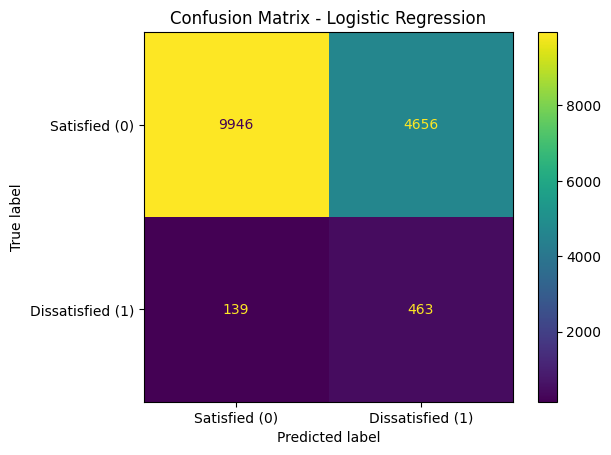

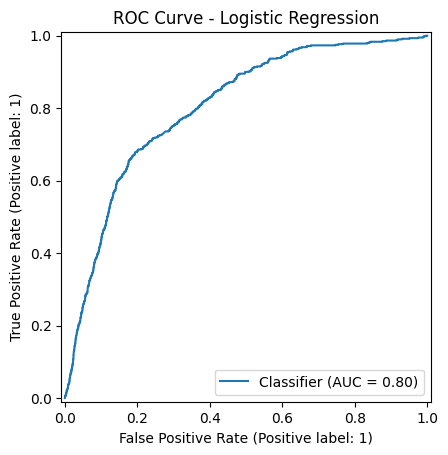

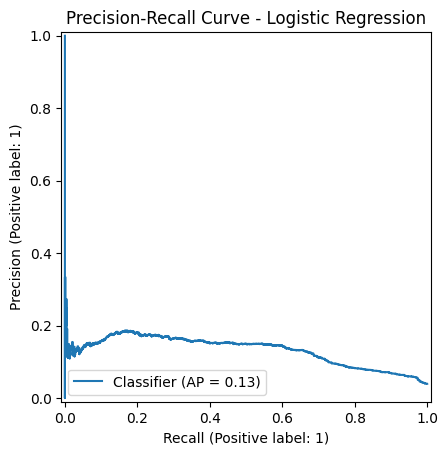

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

ConfusionMatrixDisplay.from_predictions(
    y_val,
    log_reg_preds,
    display_labels=["Satisfied (0)", "Dissatisfied (1)"]
)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

RocCurveDisplay.from_predictions(y_val, log_reg_probs)
plt.title("ROC Curve - Logistic Regression")
plt.show()

PrecisionRecallDisplay.from_predictions(y_val, log_reg_probs)
plt.title("Precision-Recall Curve - Logistic Regression")
plt.show()

The confusion matrix shows that logistic regression identifies 463 out of 602 dissatisfied customers in the validation set, while missing 139. this explains the model’s high recall for class 1. However, the model also incorrectly labels 4,653 satisfied customers as dissatisfied, which explains the low precision.

The ROC curve gives an AUC of 0.80, meaning the model has a good ability to rank dissatisfied customers above satisfied customers.

The average precision is 0.13, which is higher than the dissatisfied customer rate of about 0.04.

,Threshold,Accuracy,Precision,Recall,F1-score
0,0.05,0.086622,0.041232,0.991694,0.079172
1,0.10,0.104183,0.042007,0.991694,0.080599
2,0.15,0.138385,0.043402,0.986711,0.083147
3,0.20,0.289661,0.051539,0.973422,0.097895
4,0.25,0.471586,0.064973,0.921927,0.121391
5,0.30,0.538740,0.071629,0.890365,0.132591
6,0.35,0.579190,0.075322,0.853821,0.138433
7,0.40,0.612865,0.079299,0.827243,0.144725
8,0.45,0.645159,0.083290,0.795681,0.150795
9,0.50,0.684622,0.090447,0.769103,0.161860


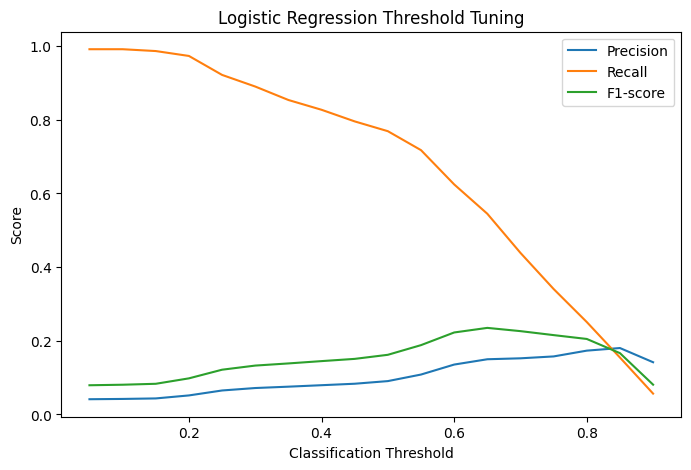

In [34]:
thresholds = np.arange(0.05, 0.95, 0.05)

threshold_results = []

for threshold in thresholds:
    preds = (log_reg_probs >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_val, preds),
        "Precision": precision_score(y_val, preds, zero_division=0),
        "Recall": recall_score(y_val, preds, zero_division=0),
        "F1-score": f1_score(y_val, preds, zero_division=0)
    })

threshold_results = pd.DataFrame(threshold_results)

display(threshold_results)

plt.figure(figsize=(8, 5))
plt.plot(threshold_results["Threshold"], threshold_results["Precision"], label="Precision")
plt.plot(threshold_results["Threshold"], threshold_results["Recall"], label="Recall")
plt.plot(threshold_results["Threshold"], threshold_results["F1-score"], label="F1-score")
plt.title("Logistic Regression Threshold Tuning")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

In [35]:
best_log_threshold = threshold_results.loc[
    threshold_results["F1-score"].idxmax(), 
    "Threshold"
]

print("Best threshold based on F1-score:", best_log_threshold)

log_reg_best_preds = (log_reg_probs >= best_log_threshold).astype(int)

print("Logistic Regression Performance at Best F1 Threshold")
print("Accuracy:", accuracy_score(y_val, log_reg_best_preds))
print("Precision:", precision_score(y_val, log_reg_best_preds, zero_division=0))
print("Recall:", recall_score(y_val, log_reg_best_preds, zero_division=0))
print("F1-score:", f1_score(y_val, log_reg_best_preds, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_val, log_reg_probs))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, log_reg_best_preds))

print("\nClassification Report:")
print(classification_report(y_val, log_reg_best_preds, zero_division=0))

Best threshold based on F1-score: 0.65
Logistic Regression Performance at Best F1 Threshold
Accuracy: 0.8595106550907656
Precision: 0.14977168949771688
Recall: 0.5448504983388704
F1-score: 0.2349570200573066
ROC-AUC: 0.8030905633006175

Confusion Matrix:
[[12740  1862]
 [  274   328]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.87      0.92     14602
           1       0.15      0.54      0.23       602

    accuracy                           0.86     15204
   macro avg       0.56      0.71      0.58     15204
weighted avg       0.95      0.86      0.90     15204



Using the threshold that maximized F1-score, logistic regression performed best at a threshold of 0.65. At this threshold, the model achieved 85.96% accuracy, 14.98% precision, 54.49% recall, and a 23.50% F1-score.

It predicts fewer customers as dissatisfied, which reduces false positives and improves precision. However, recall decreases because the model misses more dissatisfied customers than it did at the lower threshold.

The confusion matrix shows that the model correctly identifies 328 out of 602 dissatisfied customers while producing 1,861 false positives. 

In [36]:
from sklearn.ensemble import RandomForestClassifier

#random_forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_val)
rf_probs = rf_model.predict_proba(X_val)[:, 1]

print("Random Forest Performance")
print("Accuracy:", accuracy_score(y_val, rf_preds))
print("Precision:", precision_score(y_val, rf_preds, zero_division=0))
print("Recall:", recall_score(y_val, rf_preds, zero_division=0))
print("F1-score:", f1_score(y_val, rf_preds, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_val, rf_probs))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, rf_preds))

print("\nClassification Report:")
print(classification_report(y_val, rf_preds, zero_division=0))

Random Forest Performance
Accuracy: 0.7621678505656406
Precision: 0.10978767477990678
Recall: 0.7043189368770764
F1-score: 0.18996415770609318
ROC-AUC: 0.8276277745596221

Confusion Matrix:
[[11164  3438]
 [  178   424]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.76      0.86     14602
           1       0.11      0.70      0.19       602

    accuracy                           0.76     15204
   macro avg       0.55      0.73      0.53     15204
weighted avg       0.95      0.76      0.83     15204



,Threshold,Accuracy,Precision,Recall,F1-score
0,0.05,0.051039,0.039992,0.998339,0.076903
1,0.10,0.092081,0.041661,0.996678,0.079979
2,0.15,0.166338,0.045205,0.996678,0.086486
3,0.20,0.335964,0.055441,0.983389,0.104965
4,0.25,0.453302,0.065095,0.958472,0.121910
5,0.30,0.525914,0.072150,0.925249,0.133862
6,0.35,0.597014,0.080613,0.882060,0.147726
7,0.40,0.675151,0.090463,0.795681,0.162455
8,0.45,0.709879,0.096931,0.760797,0.171954
9,0.50,0.762168,0.109788,0.704319,0.189964


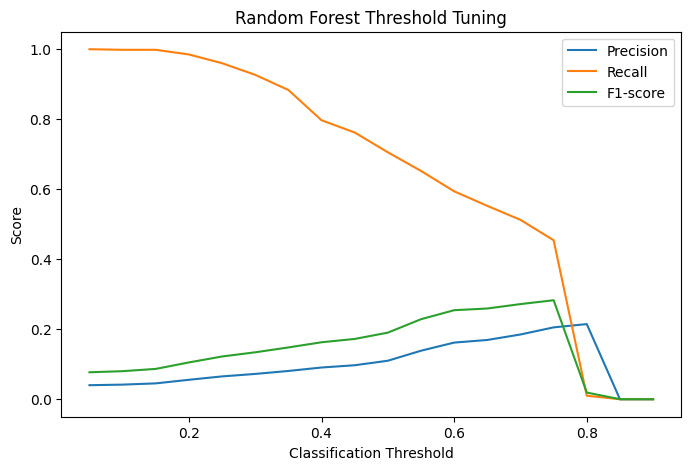

In [37]:
rf_threshold_results = []

for threshold in thresholds:
    preds = (rf_probs >= threshold).astype(int)
    
    rf_threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_val, preds),
        "Precision": precision_score(y_val, preds, zero_division=0),
        "Recall": recall_score(y_val, preds, zero_division=0),
        "F1-score": f1_score(y_val, preds, zero_division=0)
    })

rf_threshold_results = pd.DataFrame(rf_threshold_results)

display(rf_threshold_results)

plt.figure(figsize=(8, 5))
plt.plot(rf_threshold_results["Threshold"], rf_threshold_results["Precision"], label="Precision")
plt.plot(rf_threshold_results["Threshold"], rf_threshold_results["Recall"], label="Recall")
plt.plot(rf_threshold_results["Threshold"], rf_threshold_results["F1-score"], label="F1-score")
plt.title("Random Forest Threshold Tuning")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

I performed threshold tuning for the Random Forest model to understand how the classification threshold affects precision, recall, and F1-score.

At low thresholds, the model has very high recall but very low precision. This means it catches almost all dissatisfied customers but also incorrectly flags many satisfied customers. As the threshold increases, precision improves, but recall decreases.

The best F1-score occurs around a threshold of 0.75, with precision of 20.59%, recall of 43.19%, and F1-score of 27.88%. This is higher than the best F1-score from logistic regression, suggesting that Random Forest provides a better precision-recall balance on this validation set.

In [38]:
best_rf_threshold = rf_threshold_results.loc[
    rf_threshold_results["F1-score"].idxmax(),
    "Threshold"
]

print("Best Random Forest threshold based on F1-score:", best_rf_threshold)

rf_best_preds = (rf_probs >= best_rf_threshold).astype(int)

print("Random Forest Performance at Best F1 Threshold")
print("Accuracy:", accuracy_score(y_val, rf_best_preds))
print("Precision:", precision_score(y_val, rf_best_preds, zero_division=0))
print("Recall:", recall_score(y_val, rf_best_preds, zero_division=0))
print("F1-score:", f1_score(y_val, rf_best_preds, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_val, rf_probs))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, rf_best_preds))

print("\nClassification Report:")
print(classification_report(y_val, rf_best_preds, zero_division=0))

Best Random Forest threshold based on F1-score: 0.75
Random Forest Performance at Best F1 Threshold
Accuracy: 0.9087082346750855
Precision: 0.20495495495495494
Recall: 0.45348837209302323
F1-score: 0.2823164426059979
ROC-AUC: 0.8276277745596221

Confusion Matrix:
[[13543  1059]
 [  329   273]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.95     14602
           1       0.20      0.45      0.28       602

    accuracy                           0.91     15204
   macro avg       0.59      0.69      0.62     15204
weighted avg       0.95      0.91      0.92     15204



##### Near-Constant Feature Removal Experiment

Earlier, I identified features where more than 99% of rows contain the same value. I initially kept these features because rare values may still be useful in an imbalanced classification problem. To make a more principled decision, I tested whether removing near-constant features improves Random Forest performance.

In [42]:
X_train_nc_removed = X_train.drop(columns=near_constant_features, errors="ignore")
X_val_nc_removed = X_val.drop(columns=near_constant_features, errors="ignore")

print("Original X_train shape:", X_train.shape)
print("X_train shape after removing near-constant features:", X_train_nc_removed.shape)
print("Number of near-constant features removed:", X_train.shape[1] - X_train_nc_removed.shape[1])

rf_nc_removed = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_nc_removed.fit(X_train_nc_removed, y_train)

rf_nc_probs = rf_nc_removed.predict_proba(X_val_nc_removed)[:, 1]

rf_nc_threshold_results = []

for threshold in thresholds:
    preds = (rf_nc_probs >= threshold).astype(int)
    
    rf_nc_threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_val, preds),
        "Precision": precision_score(y_val, preds, zero_division=0),
        "Recall": recall_score(y_val, preds),
        "F1-score": f1_score(y_val, preds),
        "ROC-AUC": roc_auc_score(y_val, rf_nc_probs)
    })

rf_nc_threshold_results = pd.DataFrame(rf_nc_threshold_results)

best_rf_nc_row = rf_nc_threshold_results.loc[
    rf_nc_threshold_results["F1-score"].idxmax()
]

print("Best Random Forest result after removing near-constant features:")
print(best_rf_nc_row)

Original X_train shape: (60816, 306)
X_train shape after removing near-constant features: (60816, 142)
Number of near-constant features removed: 164
Best Random Forest result after removing near-constant features:
Threshold    0.750000
Accuracy     0.907064
Precision    0.202494
Recall       0.458472
F1-score     0.280916
ROC-AUC      0.831767
Name: 14, dtype: float64


In [43]:
near_constant_experiment_comparison = pd.DataFrame({
    "Experiment": [
        "Random Forest with near-constant features",
        "Random Forest without near-constant features"
    ],
    "Best Threshold": [
        best_rf_threshold,
        best_rf_nc_row["Threshold"]
    ],
    "Accuracy": [
        accuracy_score(y_val, rf_best_preds),
        best_rf_nc_row["Accuracy"]
    ],
    "Precision": [
        precision_score(y_val, rf_best_preds, zero_division=0),
        best_rf_nc_row["Precision"]
    ],
    "Recall": [
        recall_score(y_val, rf_best_preds),
        best_rf_nc_row["Recall"]
    ],
    "F1-score": [
        f1_score(y_val, rf_best_preds),
        best_rf_nc_row["F1-score"]
    ],
    "ROC-AUC": [
        roc_auc_score(y_val, rf_probs),
        best_rf_nc_row["ROC-AUC"]
    ]
})

near_constant_experiment_comparison

,Experiment,Best Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest with near-constant features,0.75,0.908708,0.204955,0.453488,0.282316,0.827628
1,Random Forest without near-constant features,0.75,0.907064,0.202494,0.458472,0.280916,0.831767


The experiment shows that removing near-constant features did not improve the Random Forest model's F1-score. The model with near-constant features achieved an F1-score of 0.2823, while the model without near-constant features achieved an F1-score of 0.2809. Although removing near-constant features slightly increased ROC-AUC from 0.8276 to 0.8318, the project prioritizes F1-score because the dataset is highly imbalanced and the goal is to balance precision and recall.

Therefore, I kept the near-constant features in the final modeling dataset. This could mean that some rare feature values may still contain useful information for identifying dissatisfied customers.

#### Gradient Boosting Classifier

To add a more advanced nonlinear model, I trained a Gradient Boosting Classifier. Gradient boosting builds trees sequentially, where each new tree attempts to correct errors made by the previous trees. This provides an additional ensemble-based model for comparison with Logistic Regression and Random Forest.

In [44]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_probs = gb_model.predict_proba(X_val)[:, 1]
gb_default_preds = (gb_probs >= 0.5).astype(int)

print("Gradient Boosting Performance at Default Threshold")
print("Accuracy:", accuracy_score(y_val, gb_default_preds))
print("Precision:", precision_score(y_val, gb_default_preds, zero_division=0))
print("Recall:", recall_score(y_val, gb_default_preds))
print("F1-score:", f1_score(y_val, gb_default_preds))
print("ROC-AUC:", roc_auc_score(y_val, gb_probs))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, gb_default_preds))

Gradient Boosting Performance at Default Threshold
Accuracy: 0.9606024730334123
Precision: 0.8
Recall: 0.006644518272425249
F1-score: 0.013179571663920923
ROC-AUC: 0.8420785324542535

Confusion Matrix:
[[14601     1]
 [  598     4]]


In [45]:
gb_threshold_results = []

for threshold in thresholds:
    preds = (gb_probs >= threshold).astype(int)

    gb_threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_val, preds),
        "Precision": precision_score(y_val, preds, zero_division=0),
        "Recall": recall_score(y_val, preds),
        "F1-score": f1_score(y_val, preds),
        "ROC-AUC": roc_auc_score(y_val, gb_probs)
    })

gb_threshold_results = pd.DataFrame(gb_threshold_results)

gb_threshold_results

,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,0.05,0.829782,0.147122,0.687708,0.242389,0.842079
1,0.10,0.882202,0.180204,0.556478,0.272247,0.842079
2,0.15,0.913049,0.205401,0.416944,0.275219,0.842079
3,0.20,0.939687,0.230769,0.224252,0.227464,0.842079
4,0.25,0.952776,0.252137,0.098007,0.141148,0.842079
5,0.30,0.959155,0.327273,0.029900,0.054795,0.842079
6,0.35,0.959945,0.347826,0.013289,0.025600,0.842079
7,0.40,0.960208,0.384615,0.008306,0.016260,0.842079
8,0.45,0.960471,0.571429,0.006645,0.013136,0.842079
9,0.50,0.960602,0.800000,0.006645,0.013180,0.842079


In [46]:
best_gb_threshold = gb_threshold_results.loc[
    gb_threshold_results["F1-score"].idxmax(),
    "Threshold"
]

print("Best Gradient Boosting threshold based on F1-score:", best_gb_threshold)

gb_best_preds = (gb_probs >= best_gb_threshold).astype(int)

print("Gradient Boosting Performance at Best F1 Threshold")
print("Accuracy:", accuracy_score(y_val, gb_best_preds))
print("Precision:", precision_score(y_val, gb_best_preds, zero_division=0))
print("Recall:", recall_score(y_val, gb_best_preds))
print("F1-score:", f1_score(y_val, gb_best_preds))
print("ROC-AUC:", roc_auc_score(y_val, gb_probs))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, gb_best_preds))

Best Gradient Boosting threshold based on F1-score: 0.15000000000000002
Gradient Boosting Performance at Best F1 Threshold
Accuracy: 0.9130491975795844
Precision: 0.20540098199672668
Recall: 0.4169435215946844
F1-score: 0.27521929824561403
ROC-AUC: 0.8420785324542535

Confusion Matrix:
[[13631   971]
 [  351   251]]


At the default threshold of 0.50, the Gradient Boosting model achieved very high accuracy and precision, but it identified almost none of the dissatisfied customers. Its recall was only 0.0066, meaning it missed nearly all positive cases. This shows why the default threshold is not suitable for this imbalanced dataset.

After threshold tuning, the best Gradient Boosting threshold based on F1-score was 0.15. At this threshold, the model achieved an F1-score of 0.2752, precision of 0.2054, recall of 0.4169, and ROC-AUC of 0.8421. Although its ROC-AUC was higher than Random Forest, its F1-score was slightly lower than the tuned Random Forest model. Since this project prioritizes F1-score for balancing precision and recall, Random Forest remains the better final model.

----

Using the threshold that maximized F1-score, the Random Forest model performed best overall. The tuned Random Forest model achieved an F1-score of 0.2823, precision of 0.2050, recall of 0.4535, and ROC-AUC of 0.8276.

The near-constant feature experiment showed that removing near-constant features slightly increased ROC-AUC but reduced F1-score from 0.2823 to 0.2809. Since this project prioritizes F1-score due to the highly imbalanced target variable, I kept the near-constant features in the final model.

The Gradient Boosting model achieved the highest ROC-AUC at 0.8421, but its best F1-score was 0.2752, which was slightly lower than Random Forest. Therefore, Random Forest was selected as the final model because it provided the best balance between precision and recall among the models tested.

#### Stratified Cross-Validation

The previous model results were based on a single 80/20 train-validation split. Since the target variable is highly imbalanced, a single split may not fully represent model performance. To obtain a more reliable estimate, I used stratified 5-fold cross-validation. Stratification preserves the proportion of satisfied and dissatisfied customers in each fold.

In [47]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [48]:
log_reg_cv_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

log_reg_cv_scores = cross_validate(
    log_reg_cv_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

log_reg_cv_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Logistic Regression Mean CV Score": [
        log_reg_cv_scores["test_accuracy"].mean(),
        log_reg_cv_scores["test_precision"].mean(),
        log_reg_cv_scores["test_recall"].mean(),
        log_reg_cv_scores["test_f1"].mean(),
        log_reg_cv_scores["test_roc_auc"].mean()
    ]
})

log_reg_cv_summary

,Metric,Logistic Regression Mean CV Score
0,Accuracy,0.691042
1,Precision,0.089816
2,Recall,0.745014
3,F1-score,0.160303
4,ROC-AUC,0.795725


In [49]:
rf_cv_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_cv_scores = cross_validate(
    rf_cv_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

rf_cv_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Random Forest Mean CV Score": [
        rf_cv_scores["test_accuracy"].mean(),
        rf_cv_scores["test_precision"].mean(),
        rf_cv_scores["test_recall"].mean(),
        rf_cv_scores["test_f1"].mean(),
        rf_cv_scores["test_roc_auc"].mean()
    ]
})

rf_cv_summary

,Metric,Random Forest Mean CV Score
0,Accuracy,0.762681
1,Precision,0.107529
2,Recall,0.683187
3,F1-score,0.185774
4,ROC-AUC,0.812714


The stratified 5-fold cross-validation results show that Random Forest performed better than Logistic Regression on the main evaluation metrics. Random Forest achieved a higher mean F1-score of 0.1858 compared with 0.1603 for Logistic Regression, and a higher mean ROC-AUC of 0.8127 compared with 0.7957.

The cross-validation F1-scores are lower than the best threshold-tuned validation results because cross-validation used the default classification threshold. However, the results still support the same overall conclusion: Random Forest is the stronger model among these two when evaluated across multiple stratified folds.

In [51]:
rf_default_preds = rf_preds

In [52]:
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline: Predict All 0",
        "Logistic Regression Default Threshold",
        "Logistic Regression Best F1 Threshold",
        "Random Forest Default Threshold",
        "Random Forest Best F1 Threshold",
        "Gradient Boosting Default Threshold",
        "Gradient Boosting Best F1 Threshold"
    ],
    "Accuracy": [
        accuracy_score(y_val, baseline_preds),
        accuracy_score(y_val, log_reg_preds),
        accuracy_score(y_val, log_reg_best_preds),
        accuracy_score(y_val, rf_default_preds),
        accuracy_score(y_val, rf_best_preds),
        accuracy_score(y_val, gb_default_preds),
        accuracy_score(y_val, gb_best_preds)
    ],
    "Precision": [
        precision_score(y_val, baseline_preds, zero_division=0),
        precision_score(y_val, log_reg_preds, zero_division=0),
        precision_score(y_val, log_reg_best_preds, zero_division=0),
        precision_score(y_val, rf_default_preds, zero_division=0),
        precision_score(y_val, rf_best_preds, zero_division=0),
        precision_score(y_val, gb_default_preds, zero_division=0),
        precision_score(y_val, gb_best_preds, zero_division=0)
    ],
    "Recall": [
        recall_score(y_val, baseline_preds),
        recall_score(y_val, log_reg_preds),
        recall_score(y_val, log_reg_best_preds),
        recall_score(y_val, rf_default_preds),
        recall_score(y_val, rf_best_preds),
        recall_score(y_val, gb_default_preds),
        recall_score(y_val, gb_best_preds)
    ],
    "F1-score": [
        f1_score(y_val, baseline_preds),
        f1_score(y_val, log_reg_preds),
        f1_score(y_val, log_reg_best_preds),
        f1_score(y_val, rf_default_preds),
        f1_score(y_val, rf_best_preds),
        f1_score(y_val, gb_default_preds),
        f1_score(y_val, gb_best_preds)
    ],
    "ROC-AUC": [
        0.5,
        roc_auc_score(y_val, log_reg_probs),
        roc_auc_score(y_val, log_reg_probs),
        roc_auc_score(y_val, rf_probs),
        roc_auc_score(y_val, rf_probs),
        roc_auc_score(y_val, gb_probs),
        roc_auc_score(y_val, gb_probs)
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Baseline: Predict All 0,0.960405,0.000000,0.000000,0.000000,0.500000
1,Logistic Regression Default Threshold,0.684622,0.090447,0.769103,0.161860,0.803091
2,Logistic Regression Best F1 Threshold,0.859511,0.149772,0.544850,0.234957,0.803091
3,Random Forest Default Threshold,0.762168,0.109788,0.704319,0.189964,0.827628
4,Random Forest Best F1 Threshold,0.908708,0.204955,0.453488,0.282316,0.827628
5,Gradient Boosting Default Threshold,0.960602,0.800000,0.006645,0.013180,0.842079
6,Gradient Boosting Best F1 Threshold,0.913049,0.205401,0.416944,0.275219,0.842079


The final model comparison shows why accuracy alone is misleading for this problem. The baseline model achieved 96.04% accuracy by predicting every customer as satisfied, but it had 0 precision, 0 recall, and 0 F1-score for the dissatisfied class.

Among the trained models, the tuned Random Forest achieved the highest F1-score at 0.2823. Gradient Boosting achieved the highest ROC-AUC at 0.8421, but its best F1-score was slightly lower at 0.2752. Since the target variable is highly imbalanced and the goal is to identify dissatisfied customers while maintaining a reasonable balance between precision and recall, I selected the tuned Random Forest model as the final model.

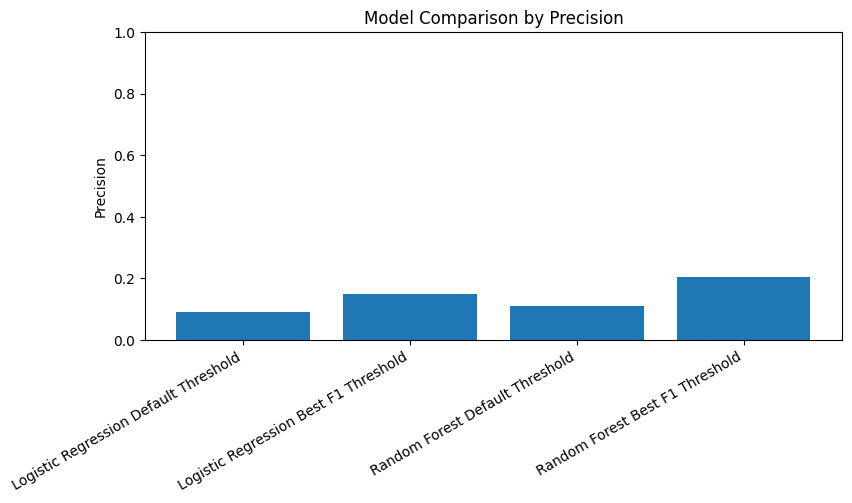

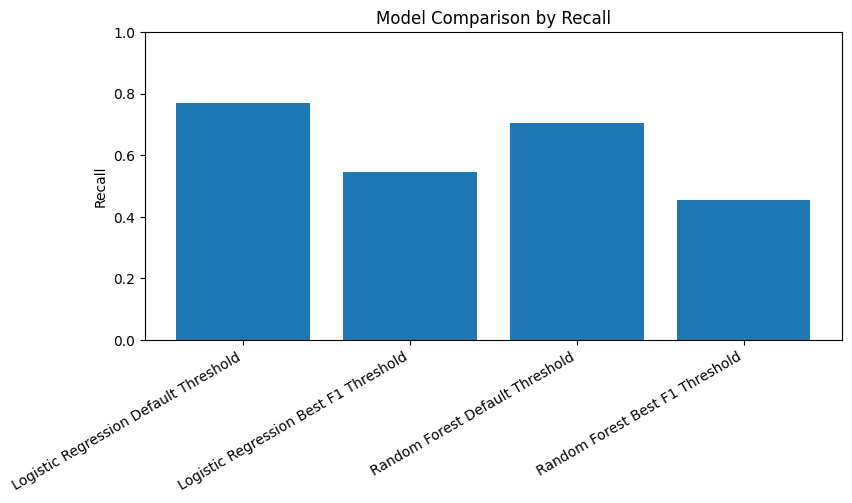

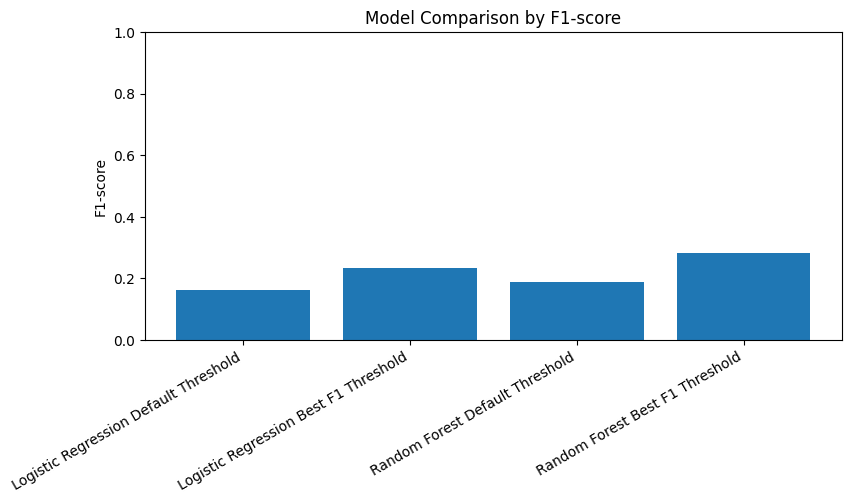

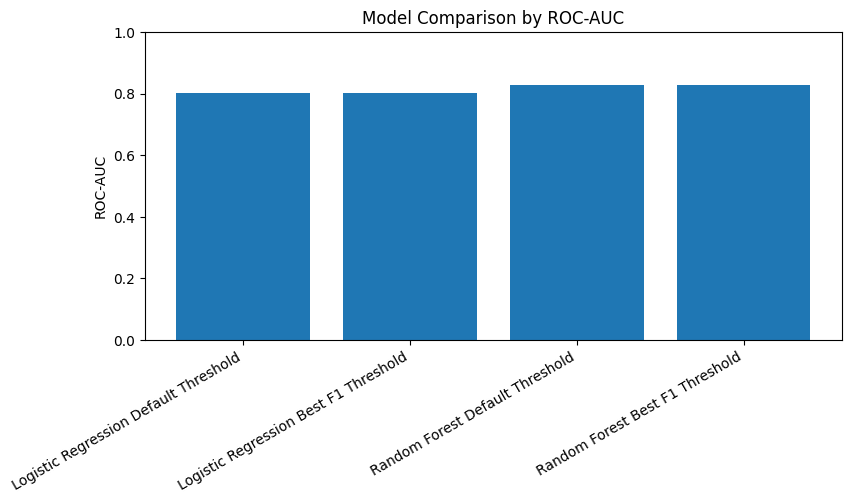

In [40]:
comparison_plot = model_comparison.copy()
comparison_plot = comparison_plot[comparison_plot["Model"] != "Baseline: Predict All 0"]

metrics_to_plot = ["Precision", "Recall", "F1-score", "ROC-AUC"]

for metric in metrics_to_plot:
    plt.figure(figsize=(9, 4))
    plt.bar(comparison_plot["Model"], comparison_plot[metric])
    plt.title(f"Model Comparison by {metric}")
    plt.ylabel(metric)
    plt.xticks(rotation=30, ha="right")
    plt.ylim(0, 1)
    plt.show()

Top 20 Random Forest feature importances:


,Feature,Importance
1,var15,0.170716
143,saldo_var30,0.062896
270,saldo_medio_var5_ult3,0.048223
128,saldo_var5,0.041312
150,saldo_var42,0.040750
269,saldo_medio_var5_ult1,0.039003
267,saldo_medio_var5_hace2,0.037811
224,num_meses_var5_ult3,0.037532
116,num_var35,0.027358
268,saldo_medio_var5_hace3,0.025800


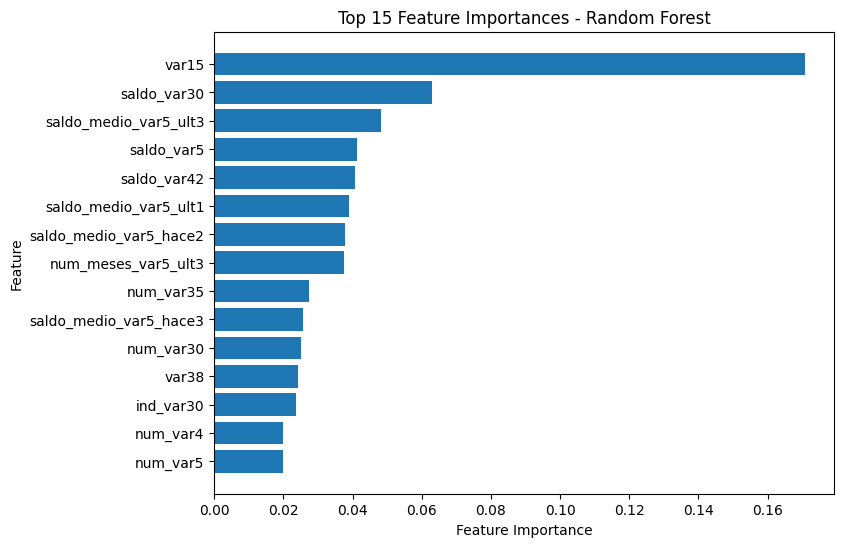

In [41]:
rf_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Top 20 Random Forest feature importances:")
display(rf_feature_importance.head(20))

plt.figure(figsize=(8, 6))
plt.barh(
    rf_feature_importance.head(15).sort_values("Importance")["Feature"],
    rf_feature_importance.head(15).sort_values("Importance")["Importance"]
)
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

The most important feature is var15, with a score of 0.171. This is consistent with the earlier exploratory analysis, where var15 showed a clear difference between satisfied and dissatisfied customers and also appeared among the top correlated features.

#### Final Test Set Predictions

After selecting the tuned Random Forest model as the final model, I retrained Random Forest on the full cleaned training dataset and generated predictions for the Kaggle test set. The final predictions were saved in a submission file with the required columns: `ID` and `TARGET`.

In [53]:
final_rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

final_rf_model.fit(X, y)

final_test_probs = final_rf_model.predict_proba(X_test_final)[:, 1]

final_test_preds = (final_test_probs >= best_rf_threshold).astype(int)

submission = pd.DataFrame({
    "ID": test_clean["ID"],
    "TARGET": final_test_preds
})

submission.head()

,ID,TARGET
0,2,0
1,5,0
2,6,0
3,7,0
4,9,0


In [54]:
submission.to_csv("santander_submission.csv", index=False)

print("Submission file created successfully.")
print("Submission shape:", submission.shape)
print("\nPredicted TARGET distribution:")
print(submission["TARGET"].value_counts(normalize=True))

Submission file created successfully.
Submission shape: (75818, 2)

Predicted TARGET distribution:
TARGET
0    0.917104
1    0.082896
Name: proportion, dtype: float64


The final submission file contains 75,818 test-set predictions with the required `ID` and `TARGET` columns. Using the selected Random Forest threshold of 0.75, the model predicted approximately 8.29% of test customers as dissatisfied and 91.71% as satisfied. This predicted positive rate is higher than the training target rate, which is expected because the selected threshold was optimized to improve recall and F1-score rather than simply match the original class distribution.

### Final Conclusion

This project aimed to predict customer dissatisfaction using the Santander Customer Satisfaction dataset. The task was challenging because the target variable was highly imbalanced, with only a small percentage of customers labeled as dissatisfied. Because of this imbalance, accuracy alone was not a reliable evaluation metric. A baseline model that predicted every customer as satisfied achieved high accuracy, but it completely failed to identify dissatisfied customers.

The dataset required several preprocessing steps before modeling. I removed constant features because they had no variation, replaced the abnormal encoded value -999999 in var3 with the median of valid training values, removed duplicate feature columns, and excluded the `ID` column from modeling because it is an identifier rather than a predictive feature. I also analyzed near-constant features and tested whether removing them improved model performance. Since removing them slightly reduced F1-score, I kept the near-constant features in the final model.

I trained and evaluated Logistic Regression, Random Forest, and Gradient Boosting models. Since the goal was to identify dissatisfied customers, I evaluated the models using precision, recall, F1-score, ROC-AUC, and confusion matrices instead of relying only on accuracy. I also tuned classification thresholds because the default threshold of 0.50 was not always appropriate for this imbalanced classification problem.

The tuned Random Forest model was selected as the final model because it achieved the highest F1-score among the models tested. It achieved an F1-score of 0.2823, precision of 0.2050, recall of 0.4535, and ROC-AUC of 0.8276 on the validation set. Although Gradient Boosting achieved a higher ROC-AUC of 0.8421, its best F1-score was slightly lower at 0.2752. Since this project prioritized balancing precision and recall, Random Forest was the stronger final choice.

The final model still had modest precision, which means many customers predicted as dissatisfied were actually satisfied. This limitation is likely due to the extreme class imbalance, anonymized features, limited domain-specific feature interpretation, and limited feature engineering. Future improvements could include using resampling methods such as SMOTE, testing more advanced boosting models such as XGBoost or LightGBM, performing additional hyperparameter tuning, and applying feature selection based on model importance scores.

Finally, I retrained the selected Random Forest model on the full cleaned training dataset and generated predictions for the Kaggle test set. The final submission file contains the required `ID` and `TARGET` columns.